# ANN for regression_Model_2
### Dataset name is "California Housing Prices"
### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)
### The dataset is 20.6K rows, can be considered as a medium dataset. It contains 7 numeric columns, 2 columns with coordinates, and one column with categorical value - text values. The target variable is "median house value". 
#### In this model i will remove high-value outliers of the target variable

In [125]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
import keras
from keras import layers

## Loading the dataset

In [126]:
# load data 
df = pd.read_csv("housing.csv")

In [127]:
# According to CharGPT is it enouth for small ANN model, good enough to learn basic patterns. 
len(df)

20640

In [128]:
# the dataset has 10 clolumns, and one "ocean_proximity" is categorical. I will need to encode it properly (one-hot encoding)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: >

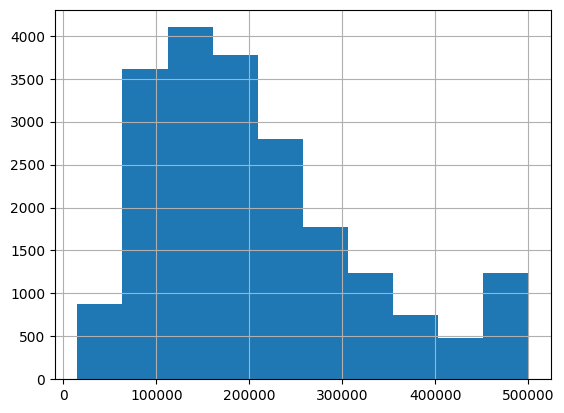

In [129]:
# this plot shows that the target variable is right-skewed, there's a smaller group of homes with very high price, this tail indicates high-value homes
# let's remove the outliers for better model performance
df['median_house_value'].hist()

In [130]:
# we will use quantiles to remove the top % in order to get closer to normal distribution
df = df.query("median_house_value < median_house_value.quantile(0.93)")

<Axes: >

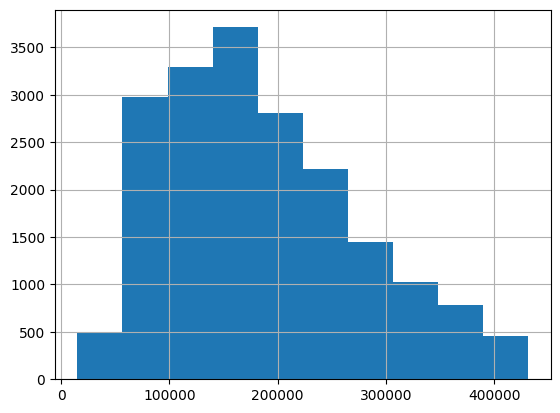

In [131]:
# now it looks better:
df['median_house_value'].hist()

In [132]:
# check if we have any missing values
df.isna().sum()

# we have missing values. I cannot fill them with median value as depends on how big a house is. I will drop them for now, not later will check how it will affect the results.

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        196
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [133]:
# dropping rows with missing values
df = df.dropna()

In [134]:
df.isna().sum()

# now we don't have any missing values

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [135]:
# check duplicates
int(df.duplicated().sum())

# no duplicates

0

## Handling the categorical variables

In [136]:
# "ocean_proximity" is nominal categorical variable, I will use one-hot encoding to convert it to numerical
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [137]:
# by using encoder we will add 5 new columns, but will remove one -  and the original one.
from sklearn.preprocessing import OneHotEncoder
variables = ['ocean_proximity']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [138]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1,0


In [139]:
# dropping the last variable:
df = df.drop("ocean_proximity_NEAR OCEAN", axis=1)

In [140]:
# let's check:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1


### Let's check the correlation between the features against each other and check distribution of support variables:

<Axes: >

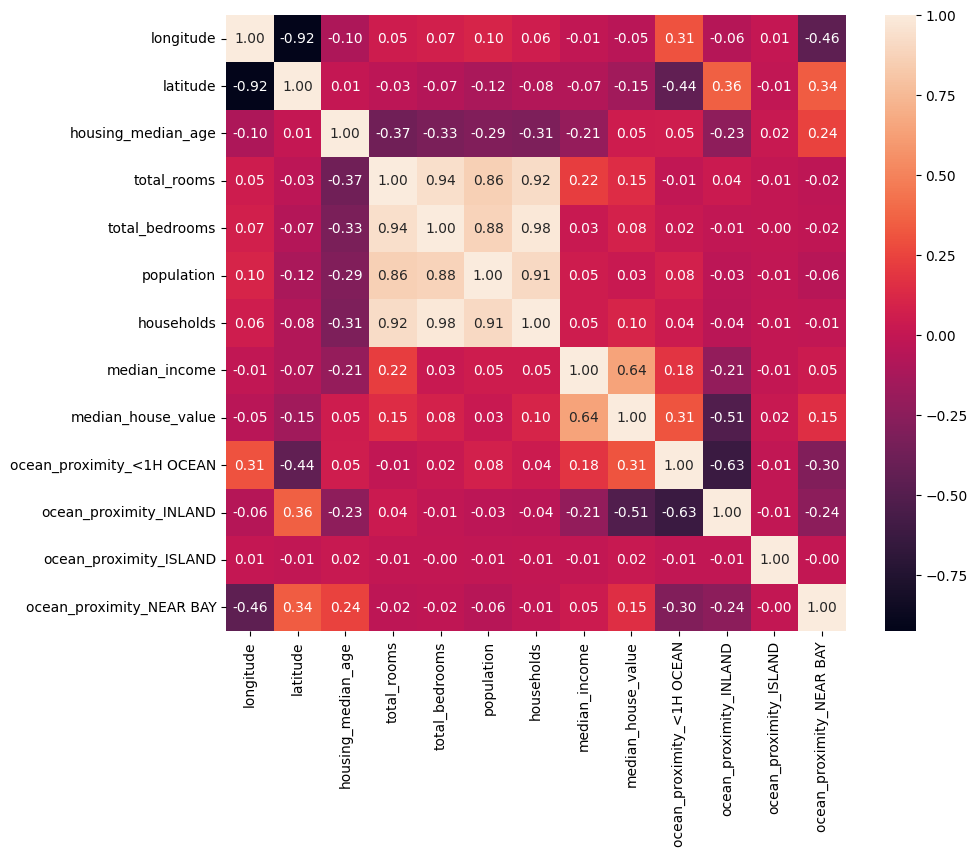

In [141]:
# it was difficult to see numbers, so we will increase the figure size:
plt.figure(figsize=(10, 8))

# on this correlation matrix we can see the most important supported variables:
# median_income. 
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt='.2f')

In [142]:
# based on my analysis of this df and correlation matrix, there is redundancy between total_bedrooms and total_rooms,
# population and households, so I will drop total_bedrooms and households as they are less correlated with the target variable.
# UPDATE 1: i will try to drop population instead on households, and compare the results,
# because in Model 1  i got much worse results after dropping households and total_bedrooms, 
# so maybe population is more redundant than households.
# UPDATE 2: result is the same as if I drop households, so it looks like it doen't matter as both these variables have low correlation with the target variable.

df = df.drop(['total_bedrooms', 'population'], axis=1)

### Support variables based on correlations are: "median_income" and "ocean_proximity_<1H OCEAN" but the last has poor connection, just 0.26.

<Axes: xlabel='median_income', ylabel='Count'>

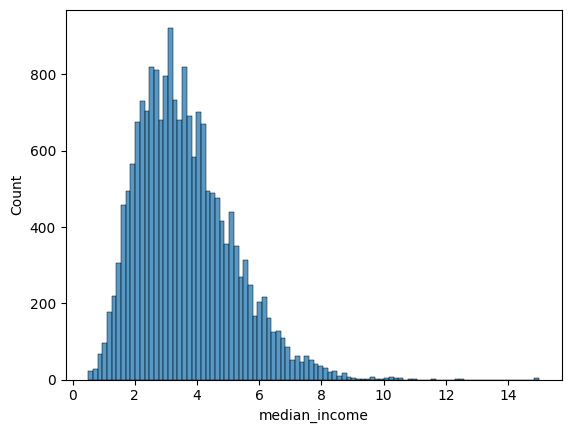

In [143]:
# let's check the distribution of median_income
sns.histplot(df['median_income'])

# this time I will remove the outliers above 99%

In [144]:
df = df.query("median_income < median_income.quantile(0.99)")

<Axes: xlabel='median_income', ylabel='Count'>

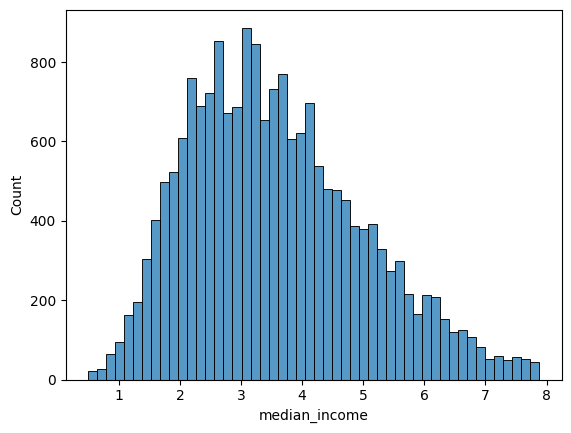

In [145]:
# looks also better:
sns.histplot(df['median_income'])

In [146]:
# as i made in all the model - drop the lon and lat
df = df.drop(['longitude', 'latitude'], axis=1)

## X/y -split

In [147]:
# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("median_house_value", axis=1)

# have only the target variable here (dependent variable)
y = df["median_house_value"]

## Train/test/validation -split

In [148]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

## Create a neural network structure

In [149]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 

# Tip: have at least the same number of nodes as in the input shape

# since we have 13 support variables this time => 16 nodes in first layer

# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(128 , activation="relu", input_shape=(variable_amount,)),
        layers.Dropout(0.1),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
model.compile(optimizer='rmsprop', loss='mse')

# common tips on how to change neural network structure if your metrics are not good:

# make wider (or narrower) layers (for example, 64 or 128 nodes)
# make a longer or shorter network (add or remove layers)
# use Dropout -layers (e.g. layers.Dropout(0.1))

# remember: there's no process or mathematical formula
# in order to figure out the optimal neural network structure
# it's mostly all about trial and error => EXPERIMENTATION!

# remember to have enough "decision-space" for your data!
# it's highly unlikely a dataset with 20 different variables is going
# to work well with only 8 nodes in each layer etc.

# print out the summary of your model
model.summary()

c:\Storage\Studies\Lapland_AMK\5_semester\Deep_learning\.venv312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,465 (40.88 KB)

 Trainable params: 10,465 (40.88 KB)

 Non-trainable params: 0 (0.00 B)

## Train the neural network

In [150]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=800, validation_data=(X_val, y_val))

Epoch 1/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 21988100096.0000 - val_loss: 20252499968.0000
Epoch 2/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18005006336.0000 - val_loss: 19901865984.0000
Epoch 3/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16987849728.0000 - val_loss: 17361981440.0000
Epoch 4/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14885223424.0000 - val_loss: 14101055488.0000
Epoch 5/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11067049984.0000 - val_loss: 9325437952.0000
Epoch 6/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8563124224.0000 - val_loss: 8462685696.0000
Epoch 7/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7949397504.0000 - val_loss: 8088006656.0000
Epoch 8/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7728605184.0000 - val_loss: 7759901696.0000
Epoch 9/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7487959040.0000 - val_loss: 7482431488.0000
Epoch 10/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2

<Axes: >

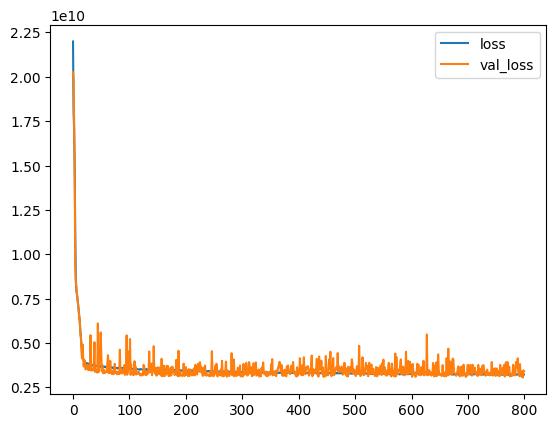

In [151]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [152]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
3572645120.0

Train data evaluation:
3424420608.0


In [153]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Test True Y,Model Predictions
0,284600.0,214959.718750
1,199800.0,239302.328125
2,412500.0,188899.875000
3,173300.0,123982.273438
4,191700.0,171996.515625
...,...,...
2817,162500.0,215002.437500
2818,271400.0,221032.187500
2819,101500.0,80523.351562
2820,112900.0,152676.656250


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

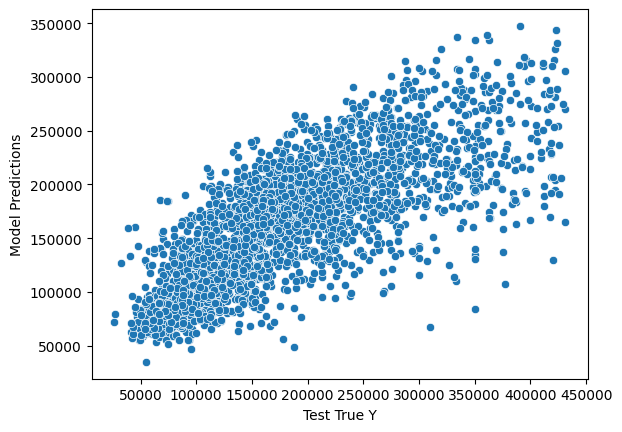

In [154]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [155]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
42204.46 $

MSE
3572644353.83 $^2

RMSE:
59771.6 $

R-squared:
0.53

Explained variance score:
0.58


C:\Users\svetl\AppData\Local\Temp\ipykernel_15476\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


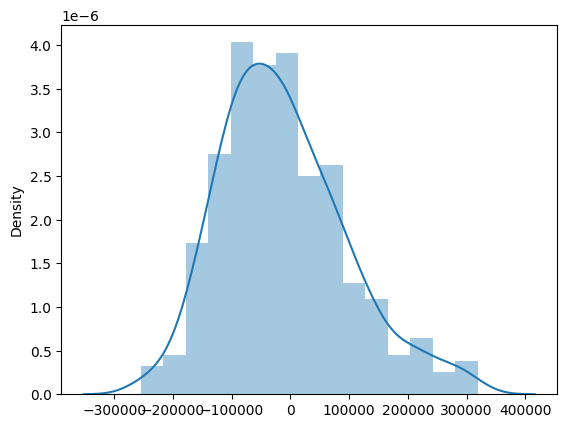

In [156]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

In [157]:
#### distribution looks quite normal, so the model is probably good enough

## Trying the model in practice with new imaginary house

In [158]:
# just to see what kind of values are usually in the dataset
# so we can test with the tester_row
df.head(3)

,housing_median_age,total_rooms,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
2,52.0,1467.0,177.0,7.2574,352100.0,0,0,0,1
3,52.0,1274.0,219.0,5.6431,341300.0,0,0,0,1
4,52.0,1627.0,259.0,3.8462,342200.0,0,0,0,1


In [159]:
# example row for testing
print(X.columns.tolist())

['housing_median_age', 'total_rooms', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY']


In [160]:
# let's try with some new imaginary data

tester_row = {
    'housing_median_age': 41.0, 
    'total_rooms': 880.0, 
    'population': 322.0, 
    'median_income': 8.3252, 
    'ocean_proximity_<1H OCEAN': 0,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [161]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Estimated house price with this example:")
print(f"$ {round(float(result[0]), 2)}")
print("----------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Estimated house price with this example:
$ 368808.72
----------------


### SUMMARY (before dropping lon,lat and ect): 
the model undersshoots the extimation, the price should be $ 452600.0 -> prediction is $ 415921.56 
In the first training, I used 32 neurons in the input layer. The model achieved an R-squared of 0.65, but the predicted house price had a significant gap compared to the actual value, indicating limited learning capacity. In the second training, I increased the input layer to 128 neurons, which significantly improved performance. The model achieved slightly better R-squared score (0,67)  and produced a more accurate price prediction. This shows that increasing the model's capacity helped it capture more complex relationships in the data and archive better result. <br>
Compare to Model_1: input layer 64: R-squared: 0.7 and prediction is $ 407610.22 -> Model_2 got better result in house proce extimation but worse result in R-squared metric.

## UPDATED (after dropping lon,lat and other)
### MODEL_2 vs MODEL_1 COMPARISON 
(rmsprop optimizer)<br>
- Model 1 R² Score: 0.67 vs Model 2 R² Score: 0.53 <br>
- Predicted price = $368 808.72 (vs actual $452 600)<br>
(adam optimazer)<br>
- Model 1 R² Score: 0.67 vs Model 2 R² Score: 0.61<br>
- Predicted price = $379 190.59 (vs actual $452 600)<br>
Removing high-value outliers from the target variable significantly reduced model performance by using different types of optimazer. This reveals that outliers contain valuable information for price prediction.<br>
**Conclusion**: Outlier removal is not good for this regression task.
